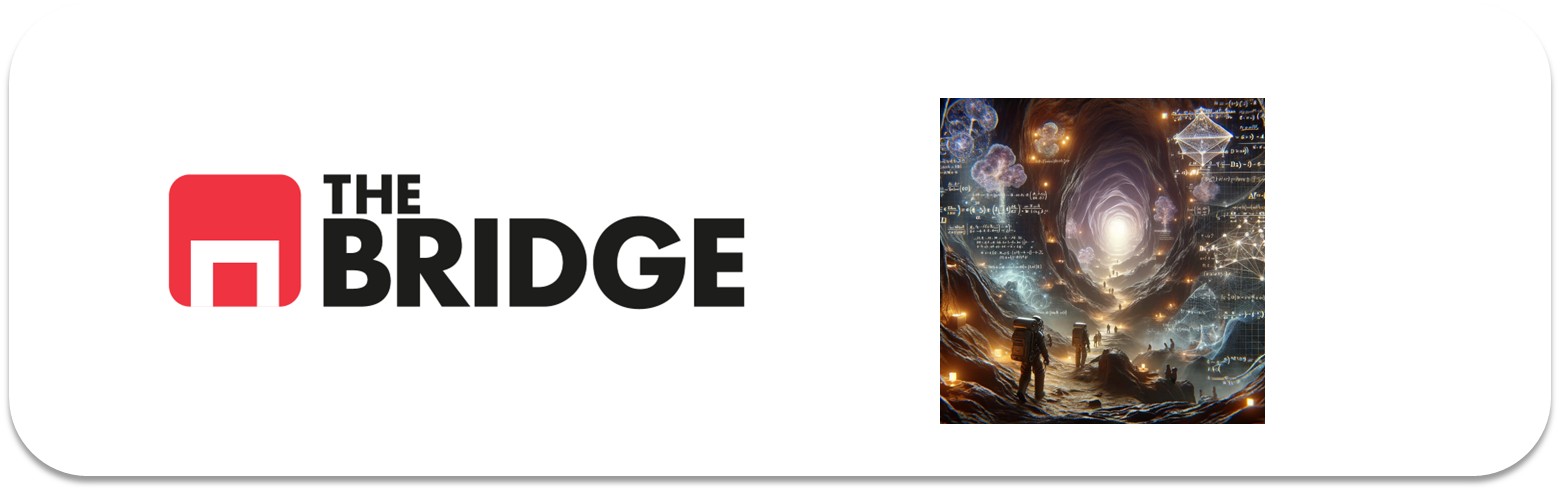

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import bootcampviztools as bt

from sklearn.model_selection import train_test_split

pd.options.mode.copy_on_write = True


### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


 ### Importación de datos

In [2]:
df = pd.read_csv("./data/titanic.csv")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


*Eliminación de duplicados*

In [6]:
df.duplicated().sum()

np.int64(107)

In [7]:
df = df.drop_duplicates()

*Eliminación de columnas*

In [8]:
df = df.drop(columns=["pclass", "embarked", "alive", "deck"], errors="ignore") 

### División del dataset

In [9]:
X = df.drop(["survived"], axis=1)
y = df["survived"].copy()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify=y)

### Distribución del target

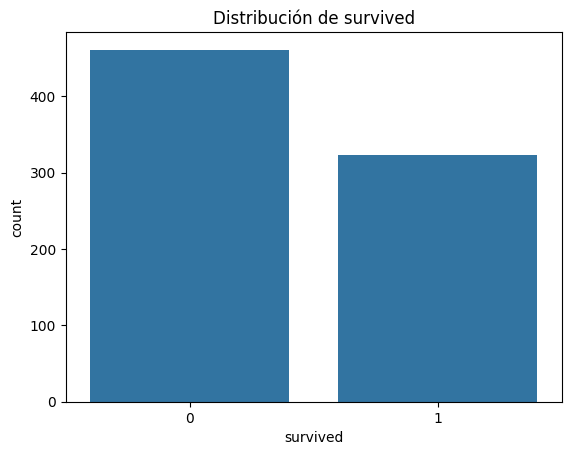

In [11]:
sns.countplot(data=df, x="survived")
plt.title("Distribución de survived")
plt.show()

### Imputación

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 627 entries, 869 to 392
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          627 non-null    object 
 1   age          542 non-null    float64
 2   sibsp        627 non-null    int64  
 3   parch        627 non-null    int64  
 4   fare         627 non-null    float64
 5   class        627 non-null    object 
 6   who          627 non-null    object 
 7   adult_male   627 non-null    bool   
 8   embark_town  625 non-null    object 
 9   alone        627 non-null    bool   
dtypes: bool(2), float64(2), int64(2), object(4)
memory usage: 45.3+ KB


In [13]:
X_train.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
869,male,4.0,1,1,11.1333,Third,child,False,Southampton,False
37,male,21.0,0,0,8.0500,Third,man,True,Southampton,True
380,female,42.0,0,0,227.5250,First,woman,False,Cherbourg,True
825,male,NaN,0,0,6.9500,Third,man,True,Queenstown,True
199,female,24.0,0,0,13.0000,Second,woman,False,Southampton,True


In [14]:
#  Máscaras por grupo en Train
es_hombre_train = X_train.who == "man"
es_mujer_train = X_train.who == "woman"
es_child_train = X_train.who == "child"

#  Medianas solo del Train
median_man = X_train[es_hombre_train]["age"].median()
median_woman = X_train[es_mujer_train]["age"].median()
median_child = X_train[es_child_train]["age"].median()

#  Máscaras de nulos
es_nulo_train = X_train.age.isna()
es_nulo_test = X_test.age.isna()

# Imputación en Train
X_train.loc[es_hombre_train & es_nulo_train, "age"] = median_man
X_train.loc[es_mujer_train & es_nulo_train, "age"] = median_woman
X_train.loc[es_child_train & es_nulo_train, "age"] = median_child

# Imputación en Test (usando medianas del Train)
X_test.loc[(X_test.who == "man") & es_nulo_test, "age"] = median_man
X_test.loc[(X_test.who == "woman") & es_nulo_test, "age"] = median_woman
X_test.loc[(X_test.who == "child") & es_nulo_test, "age"] = median_child

In [15]:
# Moda
moda_embark = X_train["embark_town"].mode()[0]

# Imputar en Train
X_train["embark_town"] = X_train["embark_town"].fillna(moda_embark)

# Imputar en Test
X_test["embark_town"] = X_test["embark_town"].fillna(moda_embark)

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 627 entries, 869 to 392
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          627 non-null    object 
 1   age          627 non-null    float64
 2   sibsp        627 non-null    int64  
 3   parch        627 non-null    int64  
 4   fare         627 non-null    float64
 5   class        627 non-null    object 
 6   who          627 non-null    object 
 7   adult_male   627 non-null    bool   
 8   embark_town  627 non-null    object 
 9   alone        627 non-null    bool   
dtypes: bool(2), float64(2), int64(2), object(4)
memory usage: 45.3+ KB


### Mini-EDA

In [17]:
features_num = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
features_cat = X_train.select_dtypes(include=["object"]).columns.tolist()

features_num, features_cat

(['age', 'sibsp', 'parch', 'fare'], ['sex', 'class', 'who', 'embark_town'])

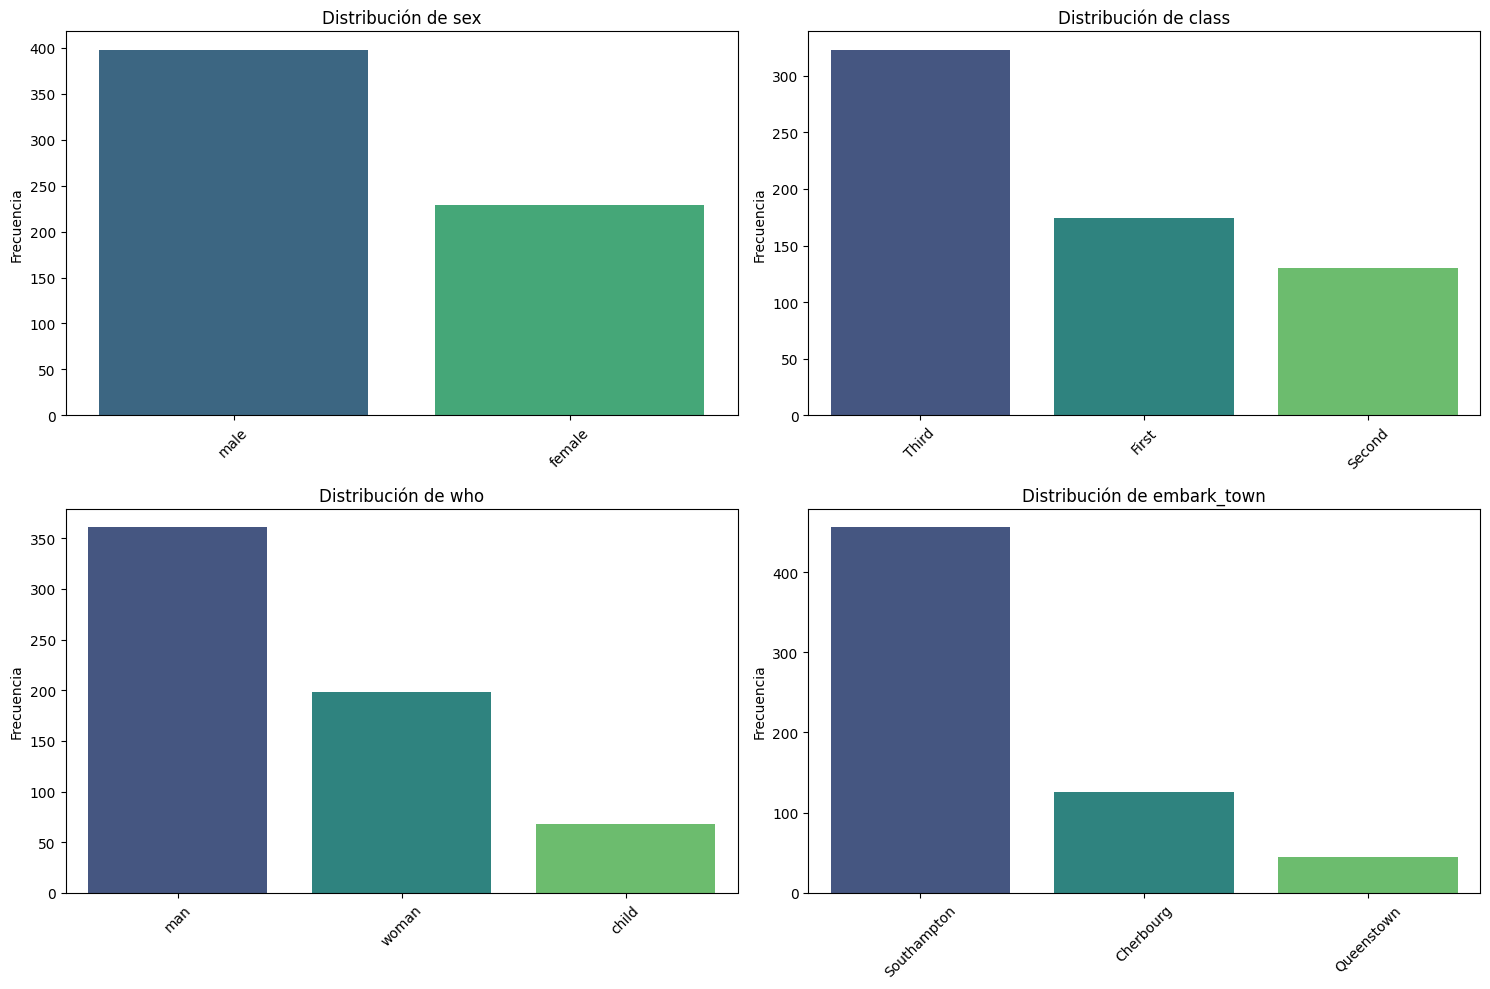

In [18]:
bt.pinta_distribucion_categoricas(X_train, features_cat, relativa=False, mostrar_valores=False)

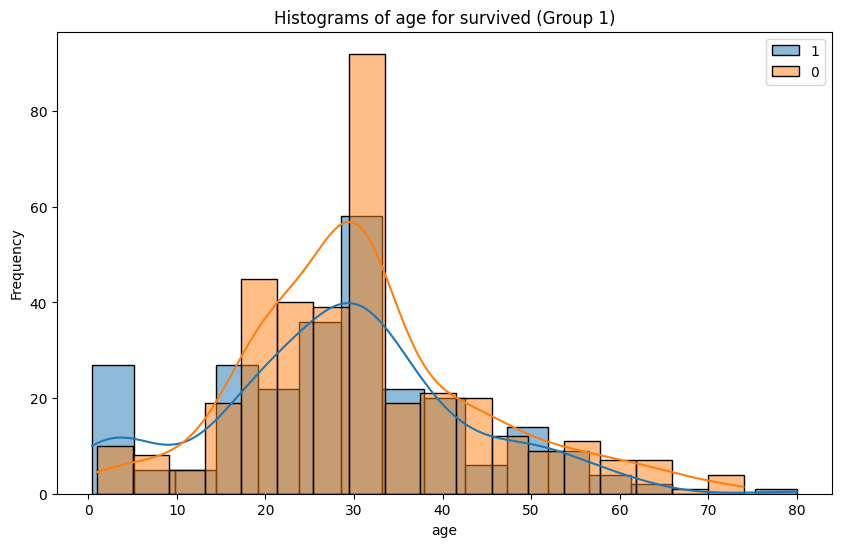

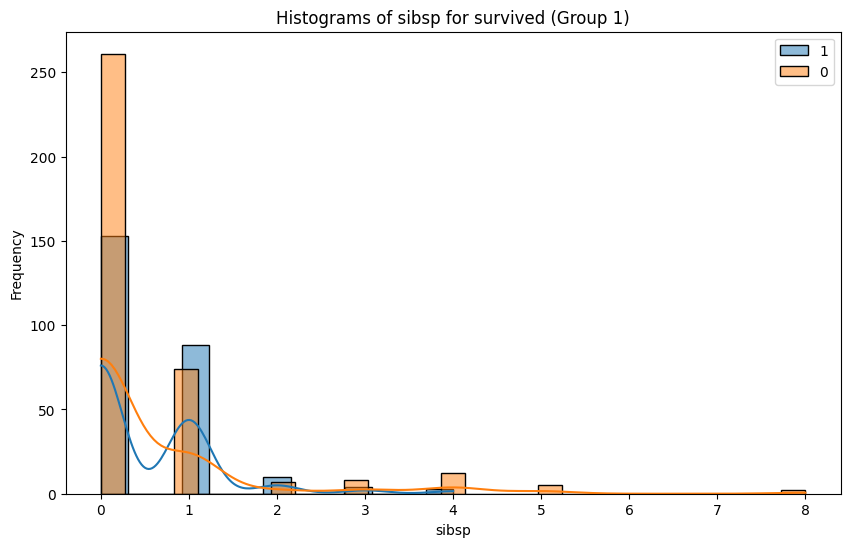

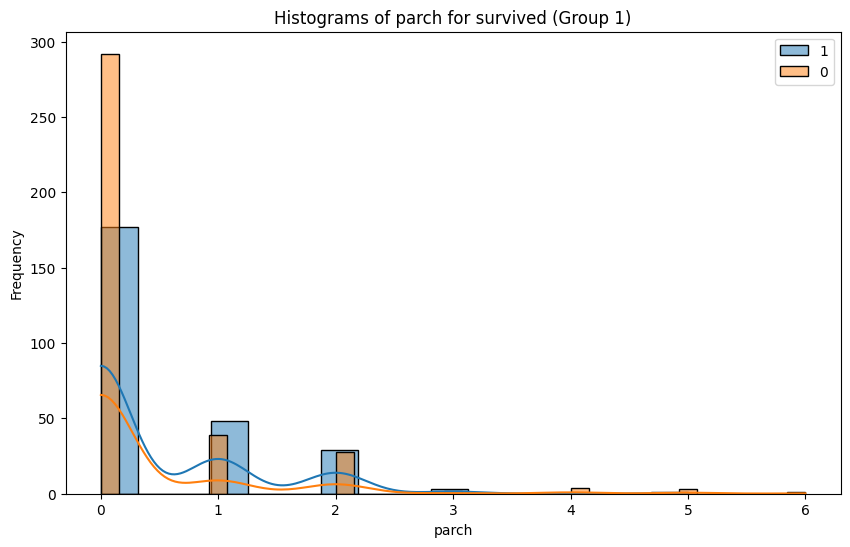

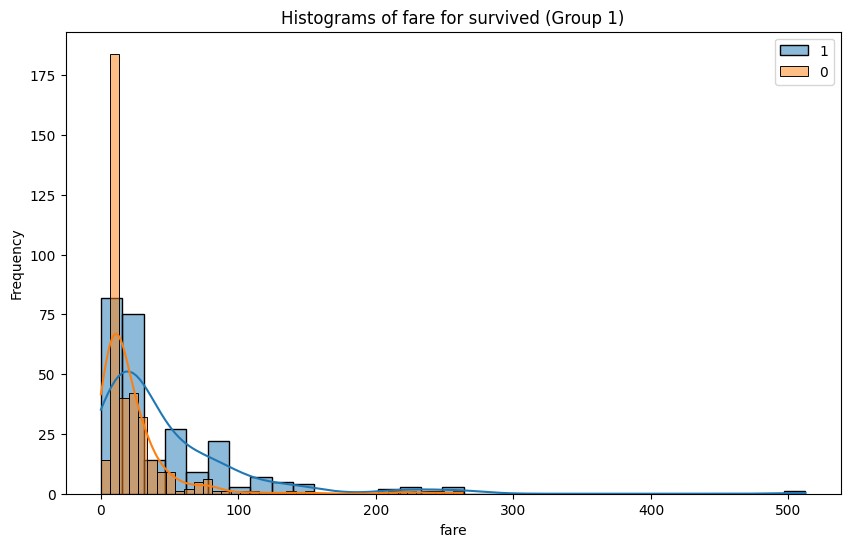

In [19]:
target = "survived"
X_train["survived"] = y_train

for col in features_num:
    bt.plot_grouped_histograms(X_train, cat_col= target, num_col= col, group_size= 2)

### Procesado de features categóricas

In [20]:
X_train = pd.get_dummies(X_train, columns=features_cat, dtype=int)
X_test = pd.get_dummies(X_test, columns=features_cat, dtype=int)

# Alinear columnas para que ambos tengan exactamente las mismas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

### Normalización

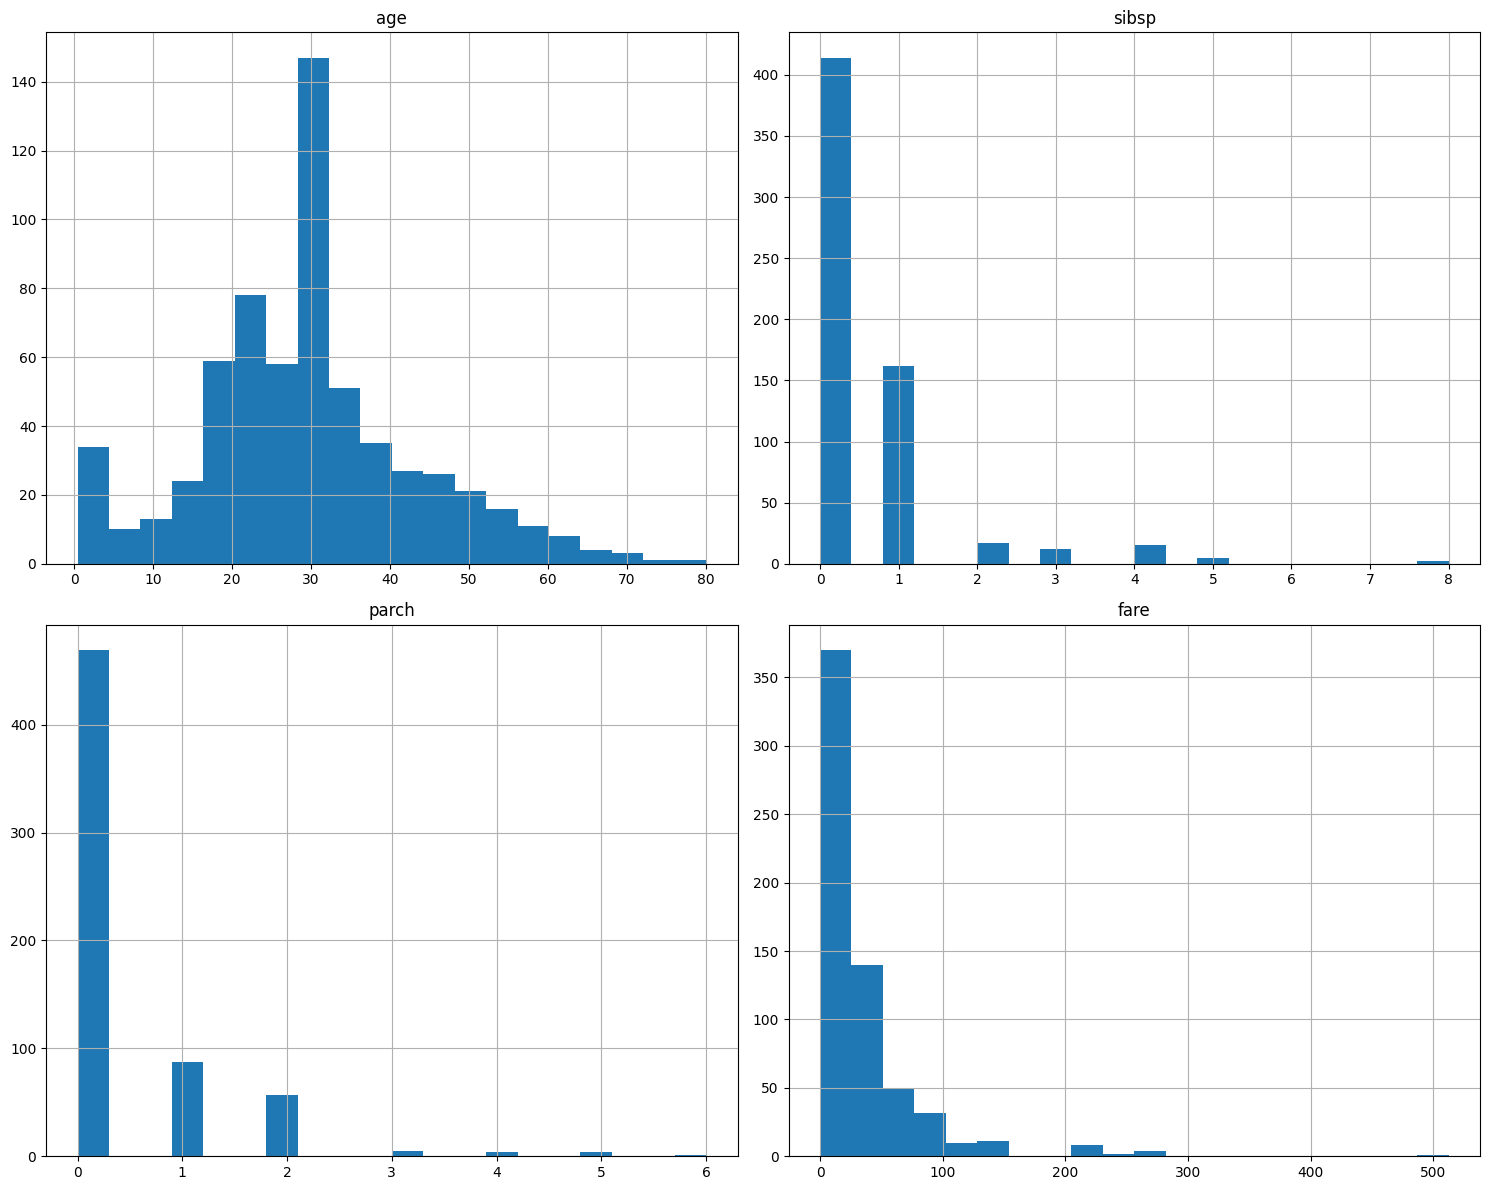

In [21]:
X_train[features_num].hist(bins=20, figsize=(15, 12))
plt.tight_layout()

In [22]:
X_train["fare"] = np.log1p(X_train["fare"])
X_test["fare"] = np.log1p(X_test["fare"])

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train[features_num])

X_train[features_num] = scaler.transform(X_train[features_num])
X_test[features_num] = scaler.transform(X_test[features_num])

In [24]:
X_train[features_num].describe()

,age,sibsp,parch,fare
count,627.000000,627.000000,627.000000,627.000000
mean,0.369059,0.066388,0.068581,0.484816
std,0.174460,0.127779,0.141910,0.150787
min,0.000000,0.000000,0.000000,0.000000
25%,0.258608,0.000000,0.000000,0.352955
50%,0.371701,0.000000,0.000000,0.453029
75%,0.447097,0.125000,0.166667,0.559529
max,1.000000,1.000000,1.000000,1.000000


### Modelado

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,  balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

*Random Forest*

In [26]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

start_rf = time.time()
grid_rf.fit(X_train, y_train)
end_rf = time.time()

best_rf = grid_rf.best_estimator_
time_rf = end_rf - start_rf

print("Mejores hiperparámetros RF:", grid_rf.best_params_)
print("Tiempo entrenamiento RF (GridSearch):", time_rf, "segundos")

Mejores hiperparámetros RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Tiempo entrenamiento RF (GridSearch): 1.4698693752288818 segundos


*MLPClassifier*

In [27]:
mlp = MLPClassifier(
    random_state=42,
    max_iter=1000,
    activation="tanh",
    solver="adam",
    learning_rate="adaptive"
)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (50,),        # 1 capa oculta
        (100,),       # 1 capa oculta
        (50, 50),     # 2 capas
        (100, 50, 25) # 3 capas
    ],
    "activation": ["relu", "tanh"],          # 'relu' es muy común
    "solver": ["adam", "sgd"],               # 'adam' es el defecto
    "alpha": [0.0001, 0.001],                # 0.0001 es el defecto
    "learning_rate": ["constant", "adaptive"]# 'constant' es el defecto
}


grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start_mlp = time.time()
grid_mlp.fit(X_train, y_train)
end_mlp = time.time()

best_mlp = grid_mlp.best_estimator_
time_mlp = end_mlp - start_mlp

print("Mejores hiperparámetros MLP:", grid_mlp.best_params_)
print("Tiempo entrenamiento MLP (GridSearch):", time_mlp, "segundos")

Mejores hiperparámetros MLP: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'adam'}
Tiempo entrenamiento MLP (GridSearch): 13.041393041610718 segundos


*Comparación de modelos*

In [28]:
# Random Forest 
start_rf_fit = time.time()
best_rf.fit(X_train, y_train)
end_rf_fit = time.time()

y_pred_rf = best_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
time_rf_fit = end_rf_fit - start_rf_fit

#  MLP (DL) 
start_mlp_fit = time.time()
best_mlp.fit(X_train, y_train)
end_mlp_fit = time.time()

y_pred_mlp = best_mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
bal_acc_mlp = balanced_accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)
time_mlp_fit = end_mlp_fit - start_mlp_fit

# Tabla comparativa 
resultados = pd.DataFrame({
    "modelo": ["Random Forest", "MLP"],
    "accuracy": [acc_rf, acc_mlp],
    "balanced_accuracy": [bal_acc_rf, bal_acc_mlp],
    "precision": [prec_rf, prec_mlp],
    "recall": [rec_rf, rec_mlp],
    "tiempo_entrenamiento": [time_rf_fit, time_mlp_fit]
})

print(resultados)

          modelo  accuracy  balanced_accuracy  precision  recall  \
0  Random Forest  0.585987                0.5        0.0     0.0   
1            MLP  0.585987                0.5        0.0     0.0   

   tiempo_entrenamiento  
0              0.059131  
1              0.109317  


c:\Users\asgr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asgr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


*Classification report y matriz de confusión del mejor modelo DL*

Classification report MLP:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        92
           1       0.00      0.00      0.00        65

    accuracy                           0.59       157
   macro avg       0.29      0.50      0.37       157
weighted avg       0.34      0.59      0.43       157



c:\Users\asgr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asgr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asgr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

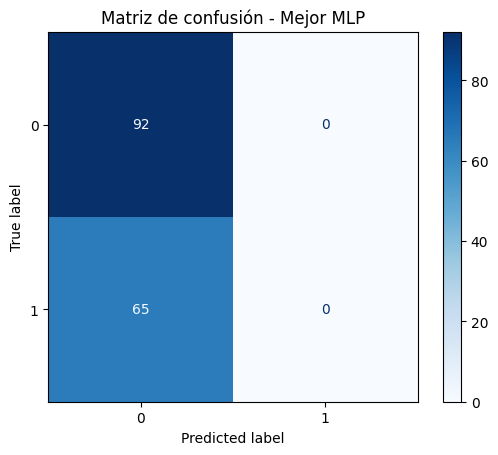

In [29]:
print("Classification report MLP:")
print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Mejor MLP")
plt.show()

Tras comparar ambos modelos el Random Forest y el MLP, podemos observar que aunque ambos obtienen una accuracy similar, el MLP no es capaz de predecir la clase minoritaria (supervivientes), lo que se refleja en su matriz de confusión y en los warnings de precisión indefinida. El Random Forest, aunque tampoco destaca ofrece un comportamiento más estable. Por lo tanto me quedaría con el Random Forest como modelo final.